In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/loan_approval - loan_approval.csv")

#Q1. Data Loading & Understanding

#a) Load the dataset into Python.
#b) Display the first 5 rows.
#c) Check the shape of the dataset.
#d) Display the data types of each column.


In [2]:
df.head(5)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [3]:
df.shape

(2000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


In [6]:
print(df.dtypes)

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


#Q2. Data Cleaning

#a) Check for missing values in the dataset.
#b) Handle missing values appropriately.
#c) Identify categorical columns present in the dataset.


In [8]:
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:\n", df.isnull().sum())



Missing values after cleaning:
 name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


In [14]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print("\nCategorical columns:", categorical_cols)


Categorical columns: ['name', 'city', 'loan_approved']


#Q3. Exploratory Data Analysis (EDA)

#a) Plot the distribution of the target variable.
#b) Analyze the relationship between one numerical feature and the target variable.
#c) Analyze the relationship between Years of Employment and the target variable

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

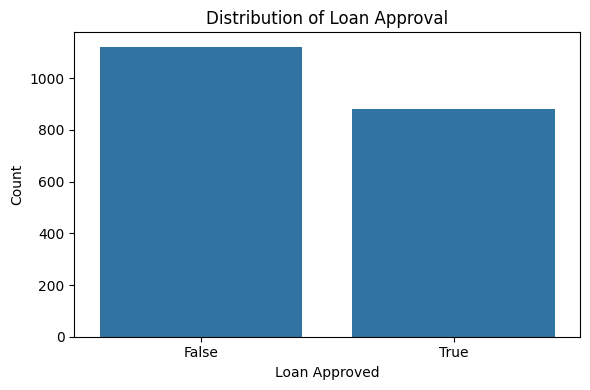

loan_approved
False    1121
True      879
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_approved', data=df)
plt.title('Distribution of Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['loan_approved'].value_counts())

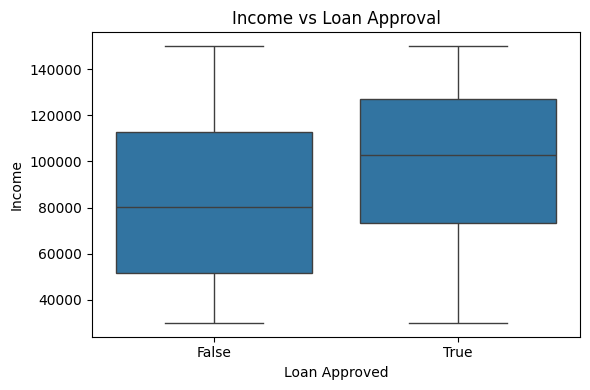

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_approved', y='income', data=df)
plt.title('Income vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Income')
plt.tight_layout()
plt.show()

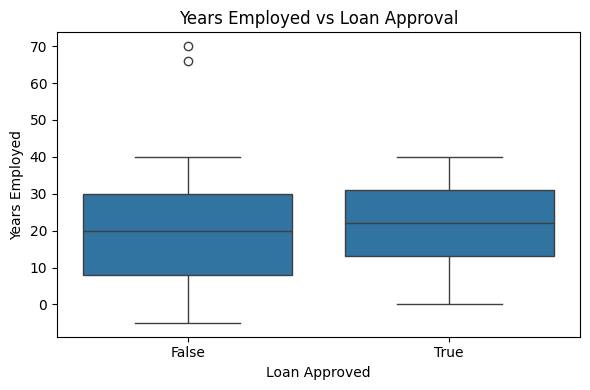

loan_approved
False    19.425513
True     21.829352
Name: years_employed, dtype: float64


In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.title('Years Employed vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Years Employed')
plt.tight_layout()
plt.show()

print(df.groupby('loan_approved')['years_employed'].mean())

#Q4. Outlier Detection and Treatment

#a) Detect outliers in numerical columns using the IQR method.
#b) Treat outliers using capping techniques


In [19]:
num_cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']


In [23]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers, lower_bound, upper_bound



In [25]:
for col in num_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers | Valid range: [{lower:.2f}, {upper:.2f}]")

income: 0 outliers | Valid range: [-26909.00, 208305.00]
credit_score: 3 outliers | Valid range: [8.50, 1140.50]
loan_amount: 0 outliers | Valid range: [-24198.88, 74328.12]
years_employed: 2 outliers | Valid range: [-21.50, 62.50]
points: 0 outliers | Valid range: [7.50, 107.50]


In [26]:
df_capped = df.copy()

for col in num_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

In [27]:
df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print("\nSummary statistics after capping:")
print(df_capped[num_cols].describe())


Summary statistics after capping:
              income  credit_score   loan_amount  years_employed       points
count    2000.000000   2000.000000   2000.000000     2000.000000  2000.000000
mean    90585.977000    579.807000  25308.503000       20.482000    56.680000
std     34487.874907    243.536494  14207.320147       11.873928    18.638033
min     30053.000000     11.000000   1022.000000       -5.000000    10.000000
25%     61296.250000    433.000000  12748.750000       10.000000    45.000000
50%     90387.500000    576.000000  25661.500000       21.000000    55.000000
75%    120099.750000    716.000000  37380.500000       31.000000    70.000000
max    149964.000000   6548.000000  49999.000000       70.000000   100.000000


#Q5. Convert target variables into numerical format suitable for model building and drop unnecessary



In [28]:
df['loan_approved'] = df['loan_approved'].astype(int)

# Drop unnecessary columns
df_model = df.drop(columns=['name', 'city'])

print(df_model.head())
print(df_model.dtypes)
print("Final shape:", df_model.shape)

   income  credit_score  loan_amount  years_employed  points  loan_approved
0  113810           389        39698              27      50              0
1   44592           729        15446              28      55              0
2   33278           584        11189              13      45              0
3  127196           344        48823              29      50              0
4   66048           496        47174               4      25              0
income            int64
credit_score      int64
loan_amount       int64
years_employed    int64
points            int64
loan_approved     int64
dtype: object
Final shape: (2000, 6)


#Q6. Feature Selection and Data Splitting

#a) Separate independent variables (X) and dependent variable (y).
#b) Split the dataset into training and testing sets.


In [29]:
from sklearn.model_selection import train_test_split
df['loan_approved'] = df['loan_approved'].astype(int)
df_model = df.drop(columns=['name', 'city'])

In [30]:
X = df_model.drop(columns=['loan_approved'])
y = df_model['loan_approved']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 5)
y shape: (2000,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  )
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (1600, 5) | X_test: (400, 5)
y_train: (1600,) | y_test: (400,)


#Q7. Apply feature scaling to the dataset using StandardScaler.


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df['loan_approved'] = df['loan_approved'].astype(int)
df_model = df.drop(columns=['name', 'city'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply feature scaling using StandardScaler
scaler = StandardScaler()

# Fit ONLY on training data, then transform both train and test
# (prevents data leakage from test set into scaling parameters)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_scaled.head())
print("\nMean (should be ~0):\n", X_train_scaled.mean())
print("\nStd (should be ~1):\n", X_train_scaled.std())

        income  credit_score  loan_amount  years_employed    points
1805 -0.173429      0.274071     0.034781       -1.146639 -0.101735
1117 -0.229602      0.462590    -1.228299        1.381899  1.256995
1863  0.464640     -0.376126     0.362460        1.466183 -0.373481
261  -0.761176      0.616483    -0.845148        1.381899  1.256995
1144  1.061643      1.008910    -1.236909       -0.303793  2.343979

Mean (should be ~0):
 income           -1.343370e-16
credit_score      2.220446e-16
loan_amount      -2.109424e-17
years_employed   -8.770762e-17
points           -1.465494e-16
dtype: float64

Std (should be ~1):
 income            1.000313
credit_score      1.000313
loan_amount       1.000313
years_employed    1.000313
points            1.000313
dtype: float64


#Q8. Logistic Regression Model Building

#a) Train a Logistic Regression model.
#b) Predict the output for test data.


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [42]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [38]:
y_pred = model.predict(X_test_scaled)          # class predictions (0/1)
y_pred_proba = model.predict_proba(X_test_scaled)  # probability estimates

print("Predicted classes (first 10):", y_pred[:10])
print("Actual classes    (first 10):", y_test.values[:10])
print("\nPredicted probabilities [P(class=0), P(class=1)] (first 5):")
print(y_pred_proba[:5])

Predicted classes (first 10): [1 0 1 1 0 1 0 1 0 0]
Actual classes    (first 10): [1 0 1 1 0 1 0 1 0 0]

Predicted probabilities [P(class=0), P(class=1)] (first 5):
[[2.25389626e-01 7.74610374e-01]
 [9.99996804e-01 3.19627045e-06]
 [7.52588888e-03 9.92474111e-01]
 [5.73864948e-05 9.99942614e-01]
 [9.99997024e-01 2.97597474e-06]]


#Q9. Model Evaluation – Confusion Matrix

#a) Generate the confusion matrix.
#b) Interpret the results.


In [39]:
from sklearn.metrics import confusion_matrix


Confusion Matrix:
 [[224   0]
 [  0 176]]

True Negatives (TN):  224
False Positives (FP): 0
False Negatives (FN): 0
True Positives (TP):  176


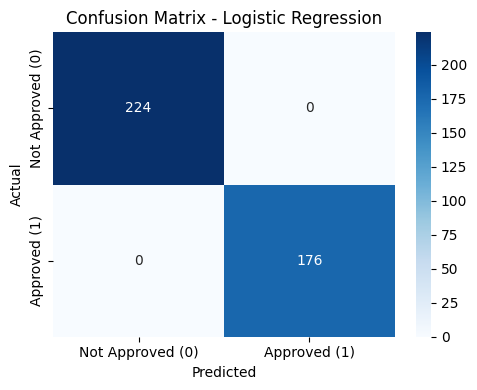

In [43]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:\n", cm)
print(f"\nTrue Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

# Visualize it
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved (0)', 'Approved (1)'],
            yticklabels=['Not Approved (0)', 'Approved (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

#True Negatives (224): Applicants correctly predicted as Not Approved.
#True Positives (176): Applicants correctly predicted as Approved.
#False Positives (0): No applicants were wrongly predicted as approved when they should've been rejected.
#False Negatives (0): No applicants were wrongly predicted as rejected when they should've been approved.

#Q10. Model Evaluation – ROC Curve & AUC

#a) Plot the ROC curve.
#b) Calculate the AUC score.

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score




In [47]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


In [54]:

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

AUC Score: 1.0


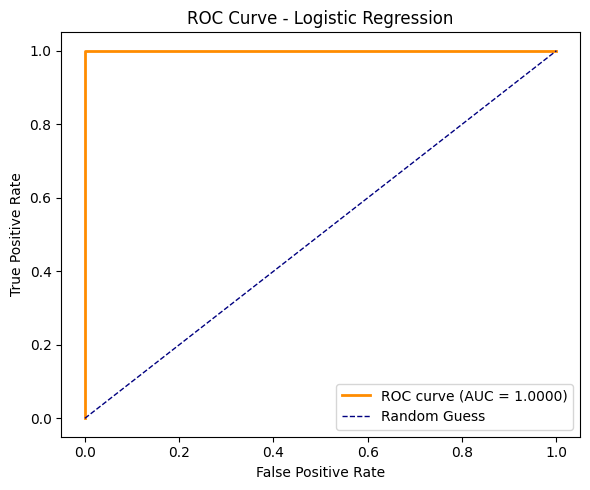

In [55]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC Score:", auc_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()